# EDA-Schema ASAP7 Analysis: Structured Dataset and QoR Study

## Introduction

This notebook presents a structured analysis of the **EDA-Schema V2 dataset** for the **ASAP7 7nm (ASAP7)** technology node.

Modern digital IC design generates heterogeneous data across multiple stages of the physical design flow, including structural netlists, physical implementation features, timing path information, and quality-of-results (QoR) metrics such as timing, power, area, wirelength, and capacitance. The EDA-Schema framework provides a unified, stage-aware representation of this data, enabling consistent analysis across the full RTL-to-GDSII pipeline.

The dataset is constructed through controlled exploration of both **timing constraints** and **physical implementation parameters**, including target clock period, aspect ratio, core utilization, and placement density. This produces a broad design space spanning timing-clean, timing-critical, and timing-violating operating regions across multiple circuit implementations.

This notebook focuses on understanding the dataset prior to downstream modeling. The analysis proceeds from **dataset construction → timing-critical operating point extraction → dataset characterization → QoR analysis → timing behavior → stage evolution → parameter sensitivity → baseline predictability**, establishing a foundation for predictive modeling and representation learning tasks.

---

## Table of Contents

1. [Dataset Setup](#dataset-setup)  
2. [Barely Pass / Barely Fail Extraction](#barely-pass--barely-fail-extraction)  
3. [Dataset Overview](#dataset-overview)  
4. [Power, Performance, Area (PPA) Analysis](#power-performance-area-ppa-analysis)  
5. [Timing Analysis](#timing-analysis)  
6. [Inter-Design Stage Analysis](#inter-design-stage-analysis)  
7. [Parameter Sensitivity Analysis](#parameter-sensitivity-analysis)  
8. [Baseline Analysis](#baseline-analysis)  
9. [Conclusions](#conclusions)

In [1]:
# Imports and configuration

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import ScalarFormatter
import seaborn as sns

from IPython.display import display, Markdown, Image

from eda_schema.dataset import Dataset
from eda_schema.db import ParquetDB
from eda_schema.entity import DesignStages


# Global configuration
warnings.filterwarnings("ignore")

## 1. Dataset Setup


This section initializes the ASAP7 dataset and constructs a unified, stage-aware dataframe for analysis.

The dataset is stored in Parquet format and provides detailed physical design information across all stages of the RTL-to-GDSII flow. The `final` stage corresponds to post-routing results and is used for QoR evaluation.

The workflow consists of:
1. Initializing dataset access  
2. Loading core tables  
3. Aggregating net-level features across stages  
4. Merging all data into a unified dataframe  

In [2]:
# Dataset configuration
PDK = "ASAP7"
DATASET_ROOT = os.environ.get("EDA_SCHEMA_V2_DATASET")
DATASET_DIR = f"../../../{DATASET_ROOT}/asap7"

FINAL_STAGE = "final"

# Verify dataset path
print("Dataset path:", DATASET_DIR)
print("Exists:", Path(DATASET_DIR).exists())

# Initialize dataset
dataset = Dataset(ParquetDB(DATASET_DIR))
print("Dataset connected")

Dataset path: ../../../../datasets/asap7
Exists: True
Dataset connected


### Load Core Dataset Tables

Load the primary tables required for analysis. These include structural, physical, and timing-related data across all design stages.

In [3]:
print("Loading core dataset tables...")

design_flow_df = dataset.db.get_table_data("design_flows")
constraint_df = dataset.db.get_table_data("constraints")
netlist_df = dataset.db.get_table_data("netlists")
cell_metrics_df = dataset.db.get_table_data("cell_metrics")
area_metrics_df = dataset.db.get_table_data("area_metrics")
power_metrics_df = dataset.db.get_table_data("power_metrics")
timing_df = dataset.db.get_table_data("timing_metrics")

# Validate loading
tables = [
    design_flow_df,
    constraint_df,
    netlist_df,
    cell_metrics_df,
    area_metrics_df,
    power_metrics_df,
    timing_df,
]

if all(not t.empty for t in tables):
    print("All core tables loaded successfully")
else:
    print("Warning: Some tables are empty")

Loading core dataset tables...
All core tables loaded successfully


### Net Aggregation Across Stages

Aggregate net-level features into a unified metric across all design stages.

- Pre-routing stages use **HPWL**  
- Post-routing stages use **routed net length**

This produces a consistent `net_length` feature for downstream analysis.

In [4]:
stage_net_agg_df_list = []

for stage in DesignStages.tolist():
    print("Loading nets for:", stage)
    
    net_df = dataset.db.get_table_data("nets", stage=stage)
    
    if stage in ["detailed_route", "final"]:
        agg_df = net_df.groupby("flow_id", as_index=False)[["length", "capacitance"]].sum()
        agg_df = agg_df.rename(columns={"length": "net_length"})
    else:
        agg_df = net_df.groupby("flow_id", as_index=False)[["hpwl", "capacitance"]].sum()
        agg_df = agg_df.rename(columns={"hpwl": "net_length"})
    
    agg_df["stage"] = stage
    stage_net_agg_df_list.append(agg_df)

# Combine all stages
net_agg_df = pd.concat(stage_net_agg_df_list, ignore_index=True)

print("Net aggregation complete")
net_agg_df.head()

Loading nets for: floorplan
Loading nets for: global_place
Loading nets for: place_resized
Loading nets for: detailed_place
Loading nets for: cts
Loading nets for: global_route
Loading nets for: detailed_route
Loading nets for: final
Net aggregation complete


,flow_id,net_length,capacitance,stage
0,ac97_ctrl-000001,0.0,0.0,floorplan
1,ac97_ctrl-000002,0.0,0.0,floorplan
2,ac97_ctrl-000003,0.0,0.0,floorplan
3,ac97_ctrl-000004,0.0,0.0,floorplan
4,ac97_ctrl-000005,0.0,0.0,floorplan


### Data Integration

Merge all dataset tables into a single unified dataframe.

This creates a stage-aware representation where each row corresponds to a `(flow_id, stage)` pair with associated structural, physical, and timing features.

In [5]:
print("Merging dataset tables...")

df = (
    design_flow_df
    .merge(constraint_df, on="flow_id")
    .merge(netlist_df, on="flow_id")
    .merge(net_agg_df, on=["flow_id", "stage"])
    .merge(cell_metrics_df, on=["flow_id", "stage"])
    .merge(area_metrics_df, on=["flow_id", "stage"])
    .merge(power_metrics_df, on=["flow_id", "stage"])
    .merge(timing_df, on=["flow_id", "stage"])
)

# Enforce stage ordering
df["stage"] = pd.Categorical(
    df["stage"],
    categories=DesignStages.tolist(),
    ordered=True
)

# Clock class (relative timing regime)
df["clock_rank"] = df.groupby("design")["clock_period"].rank(method="dense", ascending=True)
df["clock_class"] = df["clock_rank"].map({
    1: "BF-", 2: "BF", 3: "BP", 4: "BP+"
})

df["clock_class"] = pd.Categorical(
    df["clock_class"],
    ["BF-", "BF", "BP", "BP+"],
    ordered=True
)

df = df.drop(columns="clock_rank")

# Placement density (from sweep index)
flow_idx = df["flow_id"].str.split("-").str[-1].astype(int)

df["place_density"] = np.select(
    [flow_idx <= 60, flow_idx <= 90, flow_idx <= 120],
    [1.0, 1.25, 1.5],
    default=1.0
)

# Summary
print("Merged dataset summary:")
print("Shape:", df.shape)
print("Flows:", df["flow_id"].nunique())
print("Designs:", df["design"].nunique())

df.head()

Merging dataset tables...
Merged dataset summary:
Shape: (15546, 60)
Flows: 1944
Designs: 18


,flow_id,design,run_status,clock_period,clock_uncertainty,clock_latency,clock_transition,input_delay,output_delay,aspect_ratio,...,total_negative_slack,worst_slack,critical_path_startpoint,critical_path_endpoint,worst_arrival_time,worst_required_time,no_of_endpoints,no_of_violating_endpoints,clock_class,place_density
0,ac97_ctrl-000001,ac97_ctrl,Complete,0.45,0.0225,0.0045,0.034375,0.09,0.09,0.5,...,0.0,0.069620,u13_occ0_r_18__DFFE_PN0P_/QN,u5_dout_19__SDFFE_PN0P_/D,0.3565,0.4261,1451,0,BP+,1.0
1,ac97_ctrl-000001,ac97_ctrl,Complete,0.45,0.0225,0.0045,0.034375,0.09,0.09,0.5,...,0.0,0.012940,u13_occ0_r_18__DFFE_PN0P_/QN,u5_dout_16__SDFFE_PN0P_/D,0.4130,0.4259,1551,0,BP+,1.0
2,ac97_ctrl-000001,ac97_ctrl,Complete,0.45,0.0225,0.0045,0.034375,0.09,0.09,0.5,...,0.0,0.012940,u13_occ0_r_18__DFFE_PN0P_/QN,u5_dout_16__SDFFE_PN0P_/D,0.4130,0.4259,1528,0,BP+,1.0
3,ac97_ctrl-000001,ac97_ctrl,Complete,0.45,0.0225,0.0045,0.034375,0.09,0.09,0.5,...,0.0,0.009017,u13_occ0_r_18__DFFE_PN0P_/QN,u5_dout_16__SDFFE_PN0P_/D,0.4169,0.4259,1558,0,BP+,1.0
4,ac97_ctrl-000001,ac97_ctrl,Complete,0.45,0.0225,0.0045,0.034375,0.09,0.09,0.5,...,0.0,0.004297,u13_occ0_r_18__DFFE_PN0P_/QN,u5_dout_16__SDFFE_PN0P_/D,0.5306,0.5349,1504,0,BP+,1.0


---
## 2. Barely Pass / Barely Fail Extraction

This section identifies timing-critical operating points near design closure.

We focus on:
- **Barely Pass (BP):** small positive slack  
- **Barely Fail (BF):** small negative slack  

For each design, we select the configuration closest to timing closure and compute normalized timing metrics.

The result is a per-design summary of:
- Target clock period (TCP)  
- Worst slack (WS)  
- Slack-to-clock ratio (SCPR)  

In [6]:
# Configuration
BARELY_PASS_INDEX = 14
BARELY_FAIL_INDEX = 23

# Use merged dataset
bp_df = df[["flow_id", "design", "clock_period", "stage", "worst_slack"]].copy()

# Filter final stage
bp_df = bp_df[bp_df["stage"] == FINAL_STAGE].copy()

# Extract sweep index
bp_df["flow_index"] = bp_df["flow_id"].str.split("-").str[-1].astype(int)

# Label BP / BF
bp_df["class"] = np.select(
    [bp_df["flow_index"] == BARELY_PASS_INDEX, bp_df["flow_index"] == BARELY_FAIL_INDEX],
    ["Barely Pass", "Barely Fail"],
    default=None
)

bp_df = bp_df.dropna(subset=["class"])

# Compute SCPR
bp_df["SCPR"] = (bp_df["worst_slack"] / bp_df["clock_period"]) * 100

# Select closest-to-zero slack per design/class
summary = bp_df.loc[bp_df.groupby(["design", "class"])["worst_slack"].apply(lambda x: x.abs().idxmin())].reset_index(drop=True)

# Construct final table
final_table = summary.assign(TCP=summary["clock_period"], WS=summary["worst_slack"]).pivot(index="design", columns="class", values=["TCP", "WS", "SCPR"])

# Flatten columns
final_table.columns = [f"{cls}_{metric}" for metric, cls in final_table.columns]
final_table = final_table.reset_index()

# Ensure consistent column order
cols = [
    "design",
    "Barely Pass_TCP", "Barely Pass_WS", "Barely Pass_SCPR",
    "Barely Fail_TCP", "Barely Fail_WS", "Barely Fail_SCPR"
]

for c in cols:
    if c not in final_table.columns:
        final_table[c] = np.nan

final_table = final_table[cols].sort_values("design")

# Formatting
final_table["Barely Pass_SCPR"] = final_table["Barely Pass_SCPR"].map(lambda x: f"{x:.3f}%" if pd.notna(x) else "")
final_table["Barely Fail_SCPR"] = final_table["Barely Fail_SCPR"].map(lambda x: f"{x:.3f}%" if pd.notna(x) else "")

final_table["Barely Pass_WS"] = final_table["Barely Pass_WS"].round(4)
final_table["Barely Fail_WS"] = final_table["Barely Fail_WS"].round(4)

# Save and display
final_table.to_csv(f"../results/{PDK}_barelypass_barely_fail_scpr.csv", index=False)

display(final_table)

,design,Barely Pass_TCP,Barely Pass_WS,Barely Pass_SCPR,Barely Fail_TCP,Barely Fail_WS,Barely Fail_SCPR
0,ac97_ctrl,0.375,0.0030,0.802%,0.350,-0.0066,-1.896%
1,aes_core,0.750,0.0074,0.985%,0.725,-0.0105,-1.447%
2,des3_area,1.225,0.0014,0.113%,1.200,-0.0042,-0.347%
3,ethernet,0.750,0.0166,2.216%,0.725,-0.0404,-5.570%
4,i2c,0.375,0.0042,1.131%,0.350,-0.0079,-2.267%
5,jpeg,1.125,0.0343,3.051%,1.100,-0.0234,-2.129%
6,mem_ctrl,0.875,0.0006,0.074%,0.850,-0.0043,-0.508%
7,pci,0.825,0.0378,4.583%,0.810,-0.0257,-3.168%
8,sasc,0.400,0.0177,4.432%,0.375,-0.0031,-0.822%
9,simple_spi,0.325,0.0039,1.197%,0.300,-0.0052,-1.726%


## 3. Dataset Overview

This section provides a high-level characterization of the dataset at the final stage.

We analyze:
- dataset scale and structure  
- per-design statistics  
- timing path distribution  
- QoR ranges across designs  


### Final Stage Dataset

All statistics are computed at the `final` stage, representing post-routing results. Extract the dataset at the final stage. This serves as the primary dataset for all downstream analysis.

In [7]:
final_df = df[df.stage == FINAL_STAGE].copy()

print("Final dataset shape:", final_df.shape)
display(final_df.head())

Final dataset shape: (1942, 60)


,flow_id,design,run_status,clock_period,clock_uncertainty,clock_latency,clock_transition,input_delay,output_delay,aspect_ratio,...,total_negative_slack,worst_slack,critical_path_startpoint,critical_path_endpoint,worst_arrival_time,worst_required_time,no_of_endpoints,no_of_violating_endpoints,clock_class,place_density
7,ac97_ctrl-000001,ac97_ctrl,Complete,0.45,0.0225,0.0045,0.034375,0.09,0.09,0.5,...,0.0,0.013660,u13_icc_r_18__DFFE_PN0P_/QN,u11_mem_2__17__DFFE_PP_/D,0.5264,0.5401,1654,0,BP+,1.0
15,ac97_ctrl-000002,ac97_ctrl,Complete,0.45,0.0225,0.0045,0.034375,0.09,0.09,0.5,...,0.0,0.009301,u13_occ0_r_18__DFFE_PN0P_/QN,u5_dout_7__SDFFE_PN0P_/D,0.5229,0.5322,1515,0,BP+,1.0
23,ac97_ctrl-000003,ac97_ctrl,Complete,0.45,0.0225,0.0045,0.034375,0.09,0.09,0.5,...,0.0,0.011010,u13_occ0_r_18__DFFE_PN0P_/QN,u5_dout_15__SDFFE_PN0P_/D,0.5175,0.5285,1473,0,BP+,1.0
31,ac97_ctrl-000004,ac97_ctrl,Complete,0.45,0.0225,0.0045,0.034375,0.09,0.09,1.0,...,0.0,0.030760,u13_occ0_r_26__DFFE_PN0P_/QN,u6_dout_11__SDFFE_PN0P_/D,0.5296,0.5604,1614,0,BP+,1.0
39,ac97_ctrl-000005,ac97_ctrl,Complete,0.45,0.0225,0.0045,0.034375,0.09,0.09,1.0,...,0.0,0.041470,u13_icc_r_2__DFFE_PN0P_/QN,u9_mem_3__18__DFFE_PP_/D,0.5095,0.5509,1517,0,BP+,1.0


### Dataset Summary

Construct a compact view containing key structural, parameter, and configuration features for each design instance.

In [8]:
summary_columns = [
    "flow_id", "design", "clock_period", "clock_class", "aspect_ratio",
    "core_utilization", "place_density",
    "no_of_inputs", "no_of_outputs", "no_of_nets", "no_of_cells",
    "no_of_sequential_cells", "no_of_buffers", "no_of_inverters",
    "no_of_fillers", "no_of_tap_cells", "no_of_pins"
]

summary_df = final_df[summary_columns].set_index("flow_id").sort_index()

num_cols = summary_df.select_dtypes(include="number").columns
summary_df[num_cols] = summary_df[num_cols].astype(float)

print("Summary dataset shape:", summary_df.shape)

display(summary_df.head())
display(summary_df.describe().round(2))

Summary dataset shape: (1942, 16)


,design,clock_period,clock_class,aspect_ratio,core_utilization,place_density,no_of_inputs,no_of_outputs,no_of_nets,no_of_cells,no_of_sequential_cells,no_of_buffers,no_of_inverters,no_of_fillers,no_of_tap_cells,no_of_pins
flow_id,,,,,,,,,,,,,,,,
ac97_ctrl-000001,ac97_ctrl,0.45,BP+,0.5,30.0,1.0,84.0,48.0,10953.0,32626.0,2265.0,1207.0,951.0,21720.0,629.0,35395.0
ac97_ctrl-000002,ac97_ctrl,0.45,BP+,0.5,40.0,1.0,84.0,48.0,10910.0,27837.0,2265.0,1159.0,950.0,16980.0,545.0,35297.0
ac97_ctrl-000003,ac97_ctrl,0.45,BP+,0.5,50.0,1.0,84.0,48.0,10894.0,24866.0,2265.0,1136.0,953.0,14029.0,489.0,35257.0
ac97_ctrl-000004,ac97_ctrl,0.45,BP+,1.0,30.0,1.0,84.0,48.0,11006.0,32117.0,2265.0,1273.0,949.0,21147.0,764.0,35523.0
ac97_ctrl-000005,ac97_ctrl,0.45,BP+,1.0,40.0,1.0,84.0,48.0,10962.0,27424.0,2265.0,1226.0,947.0,16503.0,659.0,35425.0


,clock_period,aspect_ratio,core_utilization,place_density,no_of_inputs,no_of_outputs,no_of_nets,no_of_cells,no_of_sequential_cells,no_of_buffers,no_of_inverters,no_of_fillers,no_of_tap_cells,no_of_pins
count,1942.00,1942.00,1942.00,1942.00,1942.00,1942.00,1942.00,1942.00,1942.00,1942.00,1942.00,1942.00,1942.00,1942.00
mean,0.67,1.00,39.99,1.15,103.29,78.52,11888.16,27396.60,1642.11,1204.10,1189.54,16039.58,552.36,38000.91
std,0.32,0.41,8.16,0.19,88.63,65.67,17971.25,41395.20,2563.59,1639.57,2533.96,24819.13,631.55,55766.78
min,0.20,0.50,30.00,1.00,14.00,9.00,440.00,897.00,88.00,60.00,43.00,431.00,52.00,1353.00
25%,0.38,0.50,30.00,1.00,19.00,18.00,971.00,2464.25,182.00,139.00,104.00,1599.00,140.00,3227.00
50%,0.68,1.00,40.00,1.00,84.00,48.00,3930.50,9648.50,603.00,707.50,316.00,5979.00,331.00,13076.50
75%,0.90,1.50,50.00,1.25,162.00,129.00,11743.75,30351.25,2017.00,1238.75,760.75,16470.50,629.00,37849.50
max,1.47,1.50,50.00,1.50,260.00,215.00,62842.00,179073.00,10976.00,8234.00,10813.00,116176.00,3254.00,205524.00


Summarize the overall scale of the dataset, including design instances, structural elements, and timing paths.

In [9]:
timing_path_df = dataset.db.get_table_data("timing_paths", stage=FINAL_STAGE)

print("Design instances:", len(summary_df))
print("Total gates:", int(summary_df["no_of_cells"].sum()))
print("Total gates (excluding fillers):",
      int(summary_df["no_of_cells"].sum() - summary_df["no_of_fillers"].sum()))
print("Total nets:", int(summary_df["no_of_nets"].sum()))
print("Total pins:", int(summary_df["no_of_pins"].sum()))

print("Total timing paths:", len(timing_path_df))
print("Timing-clean paths:", (timing_path_df["slack"] >= 0).sum())
print("Timing-violating paths:", (timing_path_df["slack"] < 0).sum())

Design instances: 1942
Total gates: 53204206
Total gates (excluding fillers): 22055351
Total nets: 23086812
Total pins: 73797773
Total timing paths: 8223683
Timing-clean paths: 7968189
Timing-violating paths: 255494


**QoR Range Analysis:** Summarize the range of key QoR metrics at the final stage:

- **Area and Power:** capture physical cost and energy consumption of the design  
- **Timing (Worst Slack, TNS):** reflect timing closure and violation severity  
- **Interconnect (Wirelength, Capacitance):** characterize routing complexity and load  

Together, these metrics describe trade-offs between performance, power, and area across implementations.

In [10]:
OVERVIEW_METRIC_COLUMNS = [
    "total_area",
    "total_power",
    "worst_slack",
    "total_negative_slack",
    "net_length",
    "capacitance",
]

OVERVIEW_METRIC_LABELS = [
    "Total Area (µm²)",
    "Total Power (µW)",
    "Worst Slack (ns)",
    "Total Negative Slack (ns)",
    "Wirelength (µm)",
    "Capacitance (pF)",
]

# Print ranges
for col, label in zip(OVERVIEW_METRIC_COLUMNS, OVERVIEW_METRIC_LABELS):
    print(f"{label}: {final_df[col].min()} – {final_df[col].max()}")

# Add non-QoR metric separately
print(f"Violating Paths [count]: {final_df['no_of_violating_endpoints'].min()} – {final_df['no_of_violating_endpoints'].max()}")

Total Area (µm²): 58.0 – 9333.0
Total Power (µW): 654.0 – 115000.0
Worst Slack (ns): -0.4188 – 0.2555
Total Negative Slack (ns): -434.998943 – 0.0
Wirelength (µm): 751.681 – 591701.235
Capacitance (pF): 96.024861 – 108167.26875
Violating Paths [count]: 0 – 12123


### Per-Design Summary

Aggregate statistics at the design level to understand scale and composition across configurations.

In [11]:
design_summary = summary_df.groupby("design").agg(
    design_instances=("clock_period", "count"),
    total_gates=("no_of_cells", "sum"),
    total_fillers=("no_of_fillers", "sum"),
    total_nets=("no_of_nets", "sum"),
    total_pins=("no_of_pins", "sum")
)
design_summary["gates_excl_fillers"] = design_summary["total_gates"] - design_summary["total_fillers"]

display(design_summary)

,design_instances,total_gates,total_fillers,total_nets,total_pins,gates_excl_fillers
design,,,,,,
ac97_ctrl,108,2943767.0,1757388.0,1191771.0,3840207.0,1186379.0
aes_core,108,3771614.0,2131715.0,1668963.0,5967813.0,1639899.0
des3_area,108,851812.0,473548.0,404296.0,1371154.0,378264.0
ethernet,106,15919205.0,9346375.0,6548745.0,21564817.0,6572830.0
i2c,108,252948.0,148515.0,105090.0,348989.0,104433.0
jpeg,108,13554690.0,7904360.0,6485473.0,18739916.0,5650330.0
mem_ctrl,108,1902487.0,1122690.0,789531.0,2666354.0,779797.0
pci,108,4653470.0,2793164.0,1873608.0,6122748.0,1860306.0
sasc,108,177889.0,106038.0,72502.0,231506.0,71851.0


Aggregate timing path counts per design, including clean and violating paths.

In [12]:
timing_path_df["design"] = timing_path_df["flow_id"].str.split("-").str[0]

timing_summary = timing_path_df.groupby("design").agg(
    total_timing_paths=("slack", "count"),
    timing_clean_paths=("slack", lambda x: (x >= 0).sum()),
    timing_violating_paths=("slack", lambda x: (x < 0).sum())
)

display(timing_summary)

,total_timing_paths,timing_clean_paths,timing_violating_paths
design,,,
ac97_ctrl,661764,620880,40884
aes_core,166908,151896,15012
des3_area,28464,26494,1970
ethernet,3762463,3649877,112586
i2c,74019,68374,5645
jpeg,1004198,998931,5267
mem_ctrl,408536,388195,20341
pci,854632,849403,5229
sasc,51689,50214,1475


## 4. Power, Performance, Area (PPA) Analysis

This section analyzes the distribution of key QoR metrics at the final stage.

We examine:
- variability across designs  
- distribution shape and skew  
- differences in scale across QoR metrics  

These insights help characterize trade-offs between performance, power, and area.

### PPA Distributions Across Designs

Visualize the distribution of QoR metrics per design using violin plots.

This highlights variability, spread, and skew across different implementations.

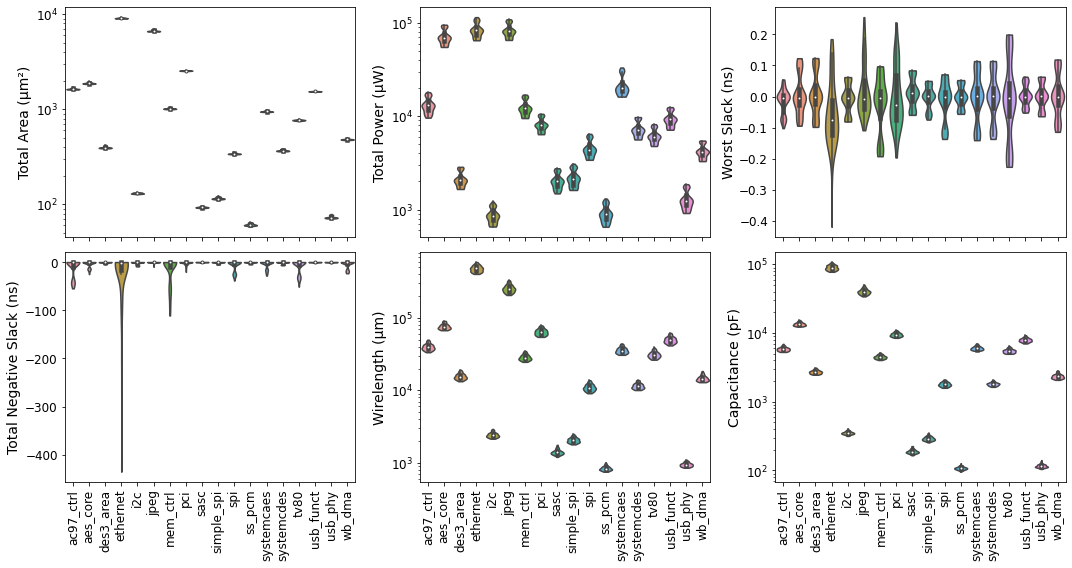

In [13]:
# -----------------------------
# 1. Display plot (2x3 layout)
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axes = axes.flatten()

for ax, col, label in zip(axes, OVERVIEW_METRIC_COLUMNS, OVERVIEW_METRIC_LABELS):
    sns.violinplot(
        data=final_df,
        x="design",
        y=col,
        order=design_summary.index,
        ax=ax,
        inner="box",
        cut=0,
        scale="width",
    )

    ax.set_xlabel("")
    ax.set_ylabel(label, fontsize=14)

    if col in ["total_area", "total_power", "net_length", "capacitance"]:
        ax.set_yscale("log")

    ax.tick_params(axis="y", labelsize=12)

# X-axis handling for 2x3
for ax in axes[:3]:  # top row
    ax.tick_params(axis="x", labelbottom=False)

for ax in axes[3:]:  # bottom row
    ax.tick_params(axis="x", rotation=90, labelsize=12)

plt.tight_layout()
plt.show()


# -----------------------------
# 2. Save original (1x6 layout)
# -----------------------------
fig_save, axes_save = plt.subplots(len(OVERVIEW_METRIC_COLUMNS), 1, figsize=(7, 4 * len(OVERVIEW_METRIC_COLUMNS)), sharex=True)

for ax, col, label in zip(axes_save, OVERVIEW_METRIC_COLUMNS, OVERVIEW_METRIC_LABELS):
    sns.violinplot(
        data=final_df,
        x="design",
        y=col,
        order=design_summary.index,
        ax=ax,
        inner="box",
        cut=0,
        scale="width",
    )

    ax.set_xlabel("")
    ax.set_ylabel(label, fontsize=16)

    if col in ["total_area", "total_power", "net_length", "capacitance"]:
        ax.set_yscale("log")

    ax.tick_params(axis="y", labelsize=12)

axes_save[-1].tick_params(axis="x", rotation=90, labelsize=12)
for ax in axes_save[:-1]:
    ax.tick_params(axis="x", labelbottom=False)

plt.tight_layout()
fig_save.savefig(f"../results/{PDK}_ppa_violin_1x6.png", dpi=300)
plt.close(fig_save)

### Global PPA Distributions

Visualize the overall distribution of QoR metrics across all flows.

Histograms highlight global spread and distribution shape.

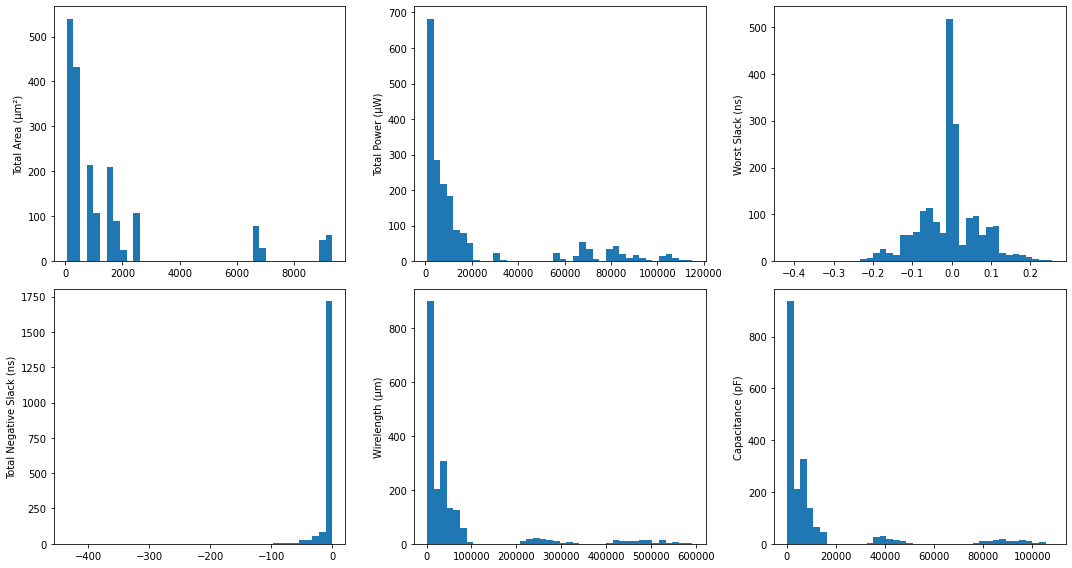

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col, label in zip(axes, OVERVIEW_METRIC_COLUMNS, OVERVIEW_METRIC_LABELS):
    data = final_df[col].dropna()
    ax.hist(data, bins=40)

    ax.set_ylabel(label)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

# Save figure
fig.savefig(f"../results/{PDK}_ppa_hist_2x3.png", dpi=300)

### Overall PPA Statistics

Summarize statistical properties of QoR metrics across all final-stage flows, including central tendency, variability, and spread.

In [15]:
ppa_stats = final_df[OVERVIEW_METRIC_COLUMNS]

overall_stats = pd.DataFrame({
    "count": ppa_stats.count(),
    "mean": ppa_stats.mean(),
    "std": ppa_stats.std(),
    "min": ppa_stats.min(),
    "25%": ppa_stats.quantile(0.25),
    "50%": ppa_stats.quantile(0.5),
    "75%": ppa_stats.quantile(0.75),
    "max": ppa_stats.max(),
    "range": ppa_stats.max() - ppa_stats.min(),
    "cv": ppa_stats.std() / ppa_stats.mean(),
}).round(4)

display(overall_stats)

,count,mean,std,min,25%,50%,75%,max,range,cv
total_area,1942,1563.6354,2375.0083,58.0000,131.0000,497.0000,1635.0000,9333.0000,9275.0000,1.5189
total_power,1942,18717.7142,28589.6573,654.0000,2060.0000,6415.0000,14375.0000,115000.0000,114346.0000,1.5274
worst_slack,1942,-0.0049,0.0742,-0.4188,-0.0475,-0.0012,0.0236,0.2555,0.6743,-15.2727
total_negative_slack,1942,-5.1049,18.6542,-434.9989,-1.2084,-0.0017,0.0000,0.0000,434.9989,-3.6542
net_length,1942,62282.7611,117186.0705,751.6810,2403.8530,19054.8170,49639.6990,591701.2350,590949.5540,1.8815
capacitance,1942,10679.0969,21281.2994,96.0249,352.4013,3138.4893,7967.5762,108167.2688,108071.2439,1.9928


Summarize the range of key QoR metrics for each design across.

In [16]:
# Build aggregation dict dynamically
agg_dict = {}
for col in OVERVIEW_METRIC_COLUMNS:
    agg_dict[f"{col}_min"] = (col, "min")
    agg_dict[f"{col}_max"] = (col, "max")

# Add non-QoR metric separately
agg_dict["violating_paths_min"] = ("no_of_violating_endpoints", "min")
agg_dict["violating_paths_max"] = ("no_of_violating_endpoints", "max")

design_range_df = final_df.groupby("design").agg(**agg_dict)

display(design_range_df)

,total_area_min,total_area_max,total_power_min,total_power_max,worst_slack_min,worst_slack_max,total_negative_slack_min,total_negative_slack_max,net_length_min,net_length_max,capacitance_min,capacitance_max,violating_paths_min,violating_paths_max
design,,,,,,,,,,,,,,
ac97_ctrl,1607.0,1700.0,9640.0,18100.0,-0.10160,0.05482,-54.627632,0.0,33588.648,50120.943,5313.930197,6967.596023,0,1657
aes_core,1847.0,1975.0,55100.0,95400.0,-0.09372,0.12340,-24.952243,0.0,67650.795,91045.657,12465.001728,15498.853413,0,613
des3_area,388.0,424.0,1660.0,2870.0,-0.09757,0.12380,-5.212110,0.0,13350.320,19217.164,2477.802574,3139.852777,0,88
ethernet,8983.0,9333.0,65000.0,115000.0,-0.41880,0.18470,-434.998943,0.0,405589.691,591701.235,78039.282984,108167.268750,0,12123
i2c,128.0,134.0,658.0,1220.0,-0.08026,0.06266,-9.106660,0.0,2154.445,2930.972,318.090123,406.858820,0,203
jpeg,6586.0,7002.0,65500.0,109000.0,-0.10840,0.25550,-9.839180,0.0,207505.786,332176.455,34196.213370,50667.456813,0,374
mem_ctrl,1001.0,1060.0,9540.0,17000.0,-0.19190,0.09732,-110.920030,0.0,24733.438,35005.981,4052.977207,5216.661328,0,1760
pci,2526.0,2581.0,6410.0,10600.0,-0.19590,0.23770,-20.379036,0.0,54723.362,78875.661,8526.398848,11033.754301,0,213
sasc,90.0,96.0,1490.0,2770.0,-0.05889,0.08427,-1.502290,0.0,1203.130,1765.538,166.245962,226.313702,0,101


## 5. Timing Analysis

This section analyzes timing behavior at the final stage, focusing on:

- timing path distribution  
- slack violations  
- worst-case timing behavior  
- total negative slack (TNS)  

These metrics characterize timing closure and identify critical designs.

### Timing Metrics Preparation

Aggregate timing path data to compute per-flow metrics including total paths, violations, worst slack, and TNS.

In [17]:
# Worst slack per flow
worst_slack_df = (
    timing_path_df.loc[
        timing_path_df.groupby("flow_id")["slack"].idxmin()
    ][["flow_id", "slack"]]
    .set_index("flow_id")
)

# Add design info
worst_slack_df["design"] = worst_slack_df.index.str.split("-").str[0]

# Aggregate metrics
total_paths = timing_path_df.groupby("flow_id").size()
violated_paths = timing_path_df[timing_path_df.slack < 0].groupby("flow_id").size()
tns = timing_path_df[timing_path_df.slack < 0].groupby("flow_id")["slack"].sum()

# Build summary
timing_summary_df = pd.DataFrame({
    "design": worst_slack_df["design"],
    "total_paths": total_paths,
    "violated_paths": violated_paths,
    "worst_slack": worst_slack_df["slack"],
    "tns": tns,
}).fillna(0)

timing_summary_df["violated_paths"] = timing_summary_df["violated_paths"].astype(int)

print(f"Flows: {len(timing_summary_df)} | Paths: {len(timing_path_df):,}")

Flows: 1942 | Paths: 8,223,683


### Per-Design Timing Summary

Aggregate timing metrics at the design level to compare timing behavior across designs.

,total_paths,violated_paths,worst_slack,tns,violation_pct
design,,,,,
ac97_ctrl,661764,40884,-0.10160,-1183.029826,6.178033
aes_core,166908,15012,-0.09372,-422.971659,8.994176
des3_area,28464,1970,-0.09757,-109.313203,6.921023
ethernet,3762463,112586,-0.41880,-2893.755571,2.992348
i2c,74019,5645,-0.08026,-216.102883,7.626420
jpeg,1004198,5267,-0.10840,-63.139050,0.524498
mem_ctrl,408536,20341,-0.19190,-1797.594046,4.978998
pci,854632,5229,-0.19590,-206.661340,0.611842
sasc,51689,1475,-0.05889,-30.104091,2.853605


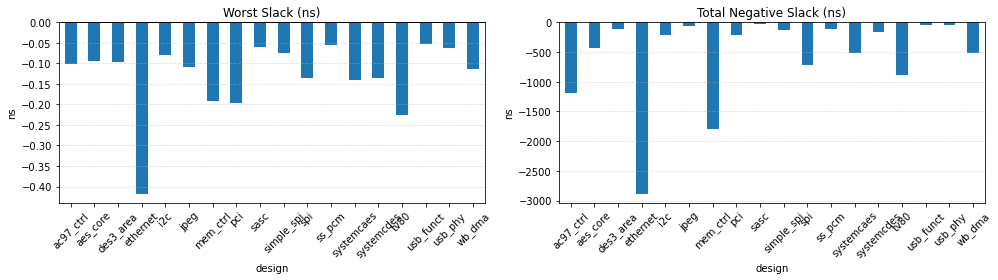

In [18]:
# Aggregate per design
design_timing_summary = timing_summary_df.groupby("design").agg(
    total_paths=("total_paths", "sum"),
    violated_paths=("violated_paths", "sum"),
    worst_slack=("worst_slack", "min"),
    tns=("tns", "sum"),
)

design_timing_summary["violation_pct"] = (
    design_timing_summary["violated_paths"] /
    design_timing_summary["total_paths"] * 100
)

display(design_timing_summary)


# -----------------------------
# Visualization
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Worst Slack
design_timing_summary["worst_slack"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Worst Slack (ns)")
axes[0].set_ylabel("ns")
axes[0].axhline(0, color="black", linewidth=1)

# TNS
design_timing_summary["tns"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Total Negative Slack (ns)")
axes[1].set_ylabel("ns")

# Formatting
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Save
fig.savefig(f"../results/{PDK}_timing_summary.png", dpi=300, bbox_inches="tight")
plt.close(fig)

### Timing Path Composition

Visualize the composition of timing-clean and violating paths per design, along with violation percentages.

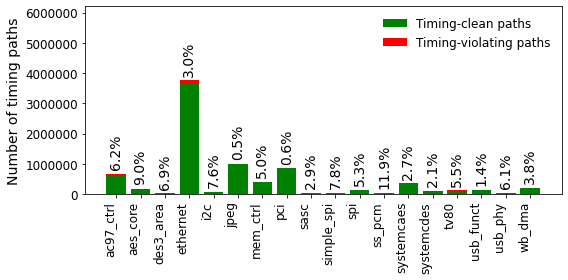

In [19]:
timing_df = design_timing_summary.copy()

# Compute clean paths and violation percentage
timing_df["clean_paths"] = timing_df["total_paths"] - timing_df["violated_paths"]
timing_df["violation_pct"] = timing_df["violated_paths"] / timing_df["total_paths"] * 100

# Sort alphabetically by design
timing_df = timing_df.sort_index()

designs = timing_df.index.tolist()
x = np.arange(len(designs))

fig, ax = plt.subplots(figsize=(8, 4))

# Stacked bars
ax.bar(x, timing_df["clean_paths"], color="green", label="Timing-clean paths")
ax.bar(x, timing_df["violated_paths"], bottom=timing_df["clean_paths"], color="red", label="Timing-violating paths")

# Add headroom for labels
y_max = timing_df["total_paths"].max()
ax.set_ylim(0, y_max * 1.65)

# Percentage labels at top of each bar
for i in range(len(x)):
    total = timing_df["total_paths"].iloc[i]
    pct = timing_df["violation_pct"].iloc[i]
    ax.text(x[i], total + 150000, f"{pct:.1f}%", ha="center", va="bottom", fontsize=14, rotation=90, clip_on=False)

# Axis formatting
ax.set_ylabel("Number of timing paths", fontsize=14)

ax.set_xticks(x)
ax.set_xticklabels(designs, rotation=90, ha="right", fontsize=12)
ax.tick_params(axis="y", labelsize=12)

# Disable scientific notation and offset
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.ticklabel_format(axis="y", style="plain")

ax.legend(fontsize=12, frameon=False)

plt.tight_layout()

# Save figure
fig.savefig(f"../results/{PDK}_timing_path_composition.png", dpi=300)

## 6. Inter-Design Stage Analysis

Analyze how key QoR metrics evolve across physical design stages.

We use **ac97_ctrl** as a representative design to study how the following metrics change from synthesis through final routing:

- **Area:** total_area [µm²]  
- **Power:** total_power [µW]  
- **Timing:** worst_slack [ns], total_negative_slack (TNS) [ns]  
- **Interconnect:** net_length (wirelength) [µm], capacitance [pF]  

This stage-wise analysis captures how design decisions and tool optimizations progressively impact QoR as the flow advances.

This helps reveal:
- where major changes occur in the flow (e.g., placement vs routing stages)  
- how early-stage estimates differ from final post-routing results  
- how variability in QoR metrics evolves across stages  
- which metrics stabilize early versus those that change significantly late in the flow  

Analyzing inter-design stage evolution for design: ac97_ctrl


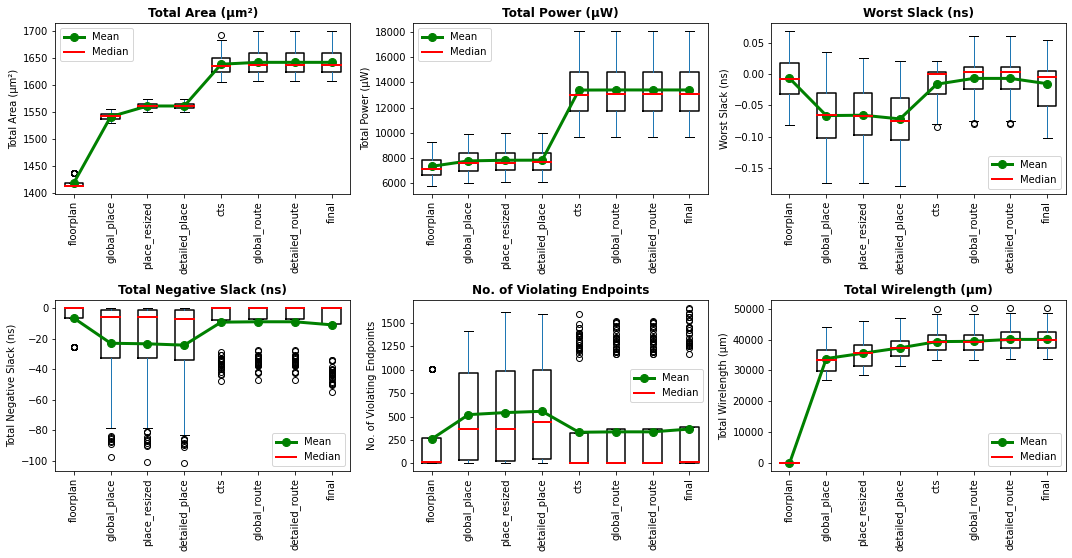

In [20]:
INTERSTAGE_METRIC_COLUMNS = [
    "total_area",
    "total_power",
    "worst_slack",
    "total_negative_slack",
    "no_of_violating_endpoints",
    "net_length",
]

INTERSTAGE_METRIC_LABELS = [
    "Total Area (µm²)",
    "Total Power (µW)",
    "Worst Slack (ns)",
    "Total Negative Slack (ns)",
    "No. of Violating Endpoints",
    "Total Wirelength (µm)",
]

# Inter-stage evolution analysis for a representative design
sample_design = "ac97_ctrl"
print(f"Analyzing inter-design stage evolution for design: {sample_design}")

# Filter data for sample design
design_data = df[df.design == sample_design].copy()
design_data.net_length = design_data.net_length

fig, axes = plt.subplots(int(len(INTERSTAGE_METRIC_COLUMNS) / 3), 3, figsize=(15, 4 * int(len(INTERSTAGE_METRIC_COLUMNS) / 3)))
axes = axes.flatten()

for i, (metric, label) in enumerate(zip(INTERSTAGE_METRIC_COLUMNS, INTERSTAGE_METRIC_LABELS)):
    ax = axes[i]

    # Box plot for each stage
    design_data.boxplot(
        column=[metric],
        by="stage",
        grid=False,
        ax=ax,
        showfliers=True,
        boxprops=dict(linewidth=1.5),
        medianprops=dict(linewidth=2, color="red"),
    )


    # Mean trend line
    stage_means = design_data.groupby("stage", observed=False)[metric].mean()
    x_positions = np.arange(1, len(stage_means) + 1)

    mean_line, = ax.plot(x_positions, stage_means.values, marker="o", color="green", linewidth=3, markersize=8, label="Mean")

    # Create median line for legend (like the red median line in the boxplot)
    median_line = mlines.Line2D([], [], color="red", linewidth=2, label="Median")

    # Append median line to existing legend
    handles, labels = ax.get_legend_handles_labels()
    handles.append(median_line)
    ax.legend(handles=handles, loc="best")

    ax.set_title(f"{label}", fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(label, fontsize=10)

    # Rotate x-axis labels
    ax.tick_params(axis="x", rotation=90)

    # Force plain formatting (NO scientific notation)
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(axis="y", style="plain")


plt.suptitle("")
plt.tight_layout()

# Save figure
fig.savefig(f"../results/{PDK}_{sample_design}_stage_evolution.png", dpi=300)

plt.show()

### QoR Distributions (Single Design)

Visualize the distribution of QoR metrics for **ac97_ctrl** across all configurations.

This highlights intra-design variability under different constraint and parameter settings.

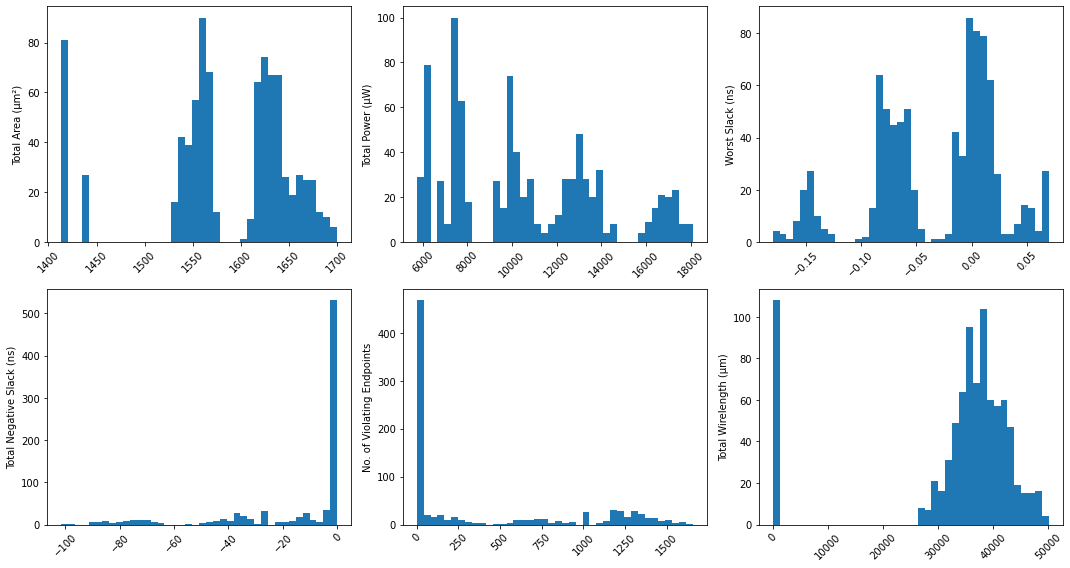

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col, label in zip(axes, INTERSTAGE_METRIC_COLUMNS, INTERSTAGE_METRIC_LABELS):
    data = design_data[col].dropna()
    ax.hist(data, bins=40)

    ax.set_ylabel(label)
    ax.set_xlabel("")

    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y")

plt.tight_layout()

# Save
fig.savefig(f"../results/{PDK}_{sample_design}_qor_hist_2x3.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Parameter Sensitivity Analysis

Analyze how key design parameters influence quality-of-result (QoR) metrics at the final stage.

This section focuses on the primary parameters used to generate the dataset:

- **Clock class (clock period):** represents the timing constraint and defines operating regimes from aggressive (BF) to relaxed (BP+). It directly impacts timing closure and strongly influences slack and TNS.  
- **Aspect ratio:** controls the geometric shape of the core. Variations affect placement distribution, routing patterns, and congestion, influencing both timing and wirelength.  
- **Core utilization:** defines how densely standard cells occupy the available area. Higher utilization increases congestion and routing difficulty, often degrading timing and increasing power.  
- **Placement density:** controls how tightly cells are packed during placement. It is a key exploration parameter that affects congestion, wirelength, and ultimately timing and power behavior.  

We study:
- **Direct relationships** through distribution-based analysis to observe trends and variability  
- **Quantitative relationships** using correlation to measure the strength and direction of parameter influence  

The analysis focuses on **ac97_ctrl** as a representative design to isolate parameter effects while minimizing cross-design variability.

Analyzing parameter sensitivity...


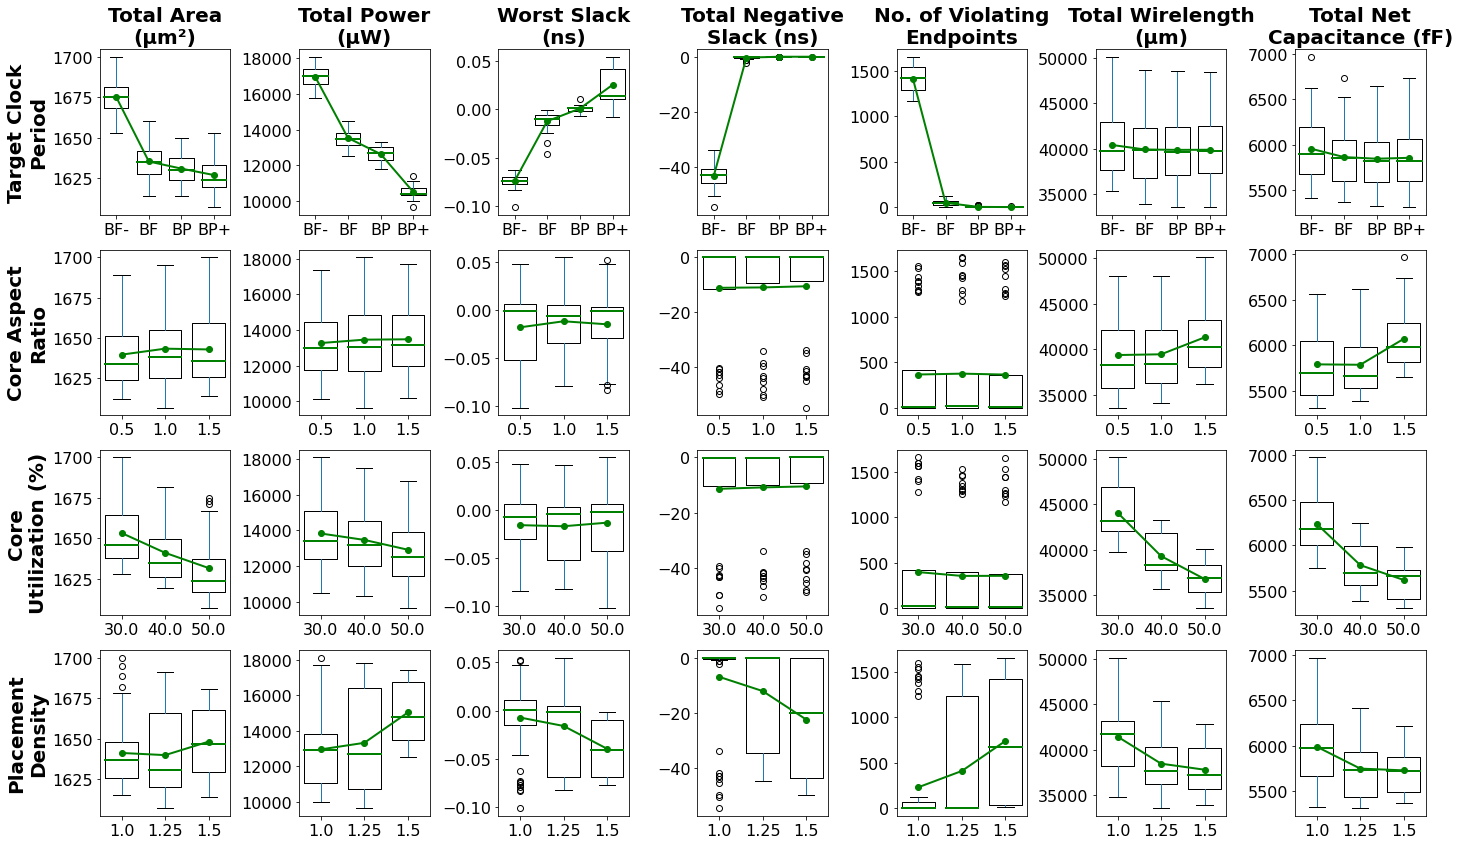

In [22]:
PARAMETERS = ["clock_class", "aspect_ratio", "core_utilization", "place_density"]

PARAMETER_LABEL_DICT = {
    "clock_class": "Target Clock\nPeriod",
    "aspect_ratio": "Core Aspect\nRatio",
    "core_utilization": "Core\nUtilization (%)",
    "place_density": "Placement\nDensity",
}

print("Analyzing parameter sensitivity...")

# Filter data
plot_df = df[
    (df.flow_id.str.startswith("ac97_ctrl")) &
    (df.stage == FINAL_STAGE)
].copy()

PARAM_SENSITIVITY_METRIC_COLUMNS = [
    "total_area",
    "total_power",
    "worst_slack",
    "total_negative_slack",
    "no_of_violating_endpoints",
    "net_length",
    "capacitance",
]

PARAM_SENSITIVITY_METRIC_LABELS = [
    "Total Area\n(µm²)",
    "Total Power\n(µW)",
    "Worst Slack\n(ns)",
    "Total Negative\nSlack (ns)",
    "No. of Violating\nEndpoints",
    "Total Wirelength\n(µm)",
    "Total Net\nCapacitance (fF)",
]

# Plot grid
fig, axes = plt.subplots(len(PARAMETERS), len(PARAM_SENSITIVITY_METRIC_COLUMNS), figsize=(20, 12), sharex=False, sharey=False)

for i, (metric, label) in enumerate(zip(PARAM_SENSITIVITY_METRIC_COLUMNS, PARAM_SENSITIVITY_METRIC_LABELS)):
    for j, param in enumerate(PARAMETERS):
        ax = axes[j, i]

        # Box plot
        plot_df.boxplot(
            column=metric,
            by=param,
            ax=ax,
            grid=False,
            showfliers=True,
            widths=0.75,
            boxprops=dict(linewidth=1),
            medianprops=dict(linewidth=2, color="green"),
        )

        # Mean trend
        means = plot_df.groupby(param, observed=False)[metric].mean()
        x = np.arange(1, len(means) + 1)

        ax.plot(x, means.values, color="green", marker="o", linewidth=2, markersize=6, label="Mean")

        # Cleanup
        ax.set_title("")
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", labelsize=16)
        ax.tick_params(axis="y", labelsize=16)

# Column titles
for i, label in enumerate(PARAM_SENSITIVITY_METRIC_LABELS):
    axes[0, i].set_title(label, fontsize=20, fontweight="bold")

# Row labels
for j, param in enumerate(PARAMETERS):
    axes[j, 0].set_ylabel(PARAMETER_LABEL_DICT.get(param, param), fontsize=20, fontweight="bold")

plt.suptitle("")
plt.tight_layout()

# Save
fig.savefig(f"../results/{PDK}_parameter_sensitivity.png", dpi=300)

plt.show()

### Correlation-Based Sensitivity

Quantify relationships between design parameters and QoR metrics using Pearson correlation.

This analysis measures the **strength and direction** of linear relationships between each parameter and metric:
- Positive correlation indicates that increasing the parameter increases the metric  
- Negative correlation indicates an inverse relationship  

Correlations are computed per design and then aggregated to capture consistent trends across the dataset. This provides a quantitative view of which parameters most strongly influence timing, power, area, and interconnect behavior.

In [23]:
print("Computing parameter-metric correlations...")

correlation_records = []

# Prepare data
corr_df = df.copy()
corr_df["clock_class"] = corr_df["clock_class"].map({
    "BF-": 1, "BF": 2, "BP": 3, "BP+": 4
})

# Compute correlations per design
for design, group in corr_df.groupby("design"):
    for param, p_label in PARAMETER_LABEL_DICT.items():
        for metric, m_label in zip(PARAM_SENSITIVITY_METRIC_COLUMNS, PARAM_SENSITIVITY_METRIC_LABELS):
            if group[param].nunique() > 1 and group[metric].nunique() > 1:
                r = group[[param, metric]].corr().iloc[0, 1]
                correlation_records.append({
                    "design": design,
                    "parameter": p_label,
                    "metric": m_label,
                    "pearson_r": r,
                    "abs_correlation": abs(r),
                })

correlation_df = pd.DataFrame(correlation_records)

print(f"Computed {len(correlation_df)} correlations")
print(f"Designs: {correlation_df['design'].nunique()}")

# Summary
corr_summary = (
    correlation_df
    .groupby(["parameter", "metric"])["pearson_r"]
    .agg(["mean", "std", "min", "max", "count"])
    .round(3)
)

print("\nCorrelation Summary")
display(corr_summary)

Computing parameter-metric correlations...
Computed 504 correlations
Designs: 18

Correlation Summary


mean    std    min    max  \
parameter             metric                                                    
Core\nUtilization (%) No. of Violating\nEndpoints -0.027  0.033 -0.123  0.021   
                      Total Area\n(µm²)           -0.065  0.030 -0.126  0.005   
                      Total Negative\nSlack (ns)   0.026  0.029 -0.012  0.116   
                      Total Net\nCapacitance (fF) -0.021  0.009 -0.035 -0.003   
                      Total Power\n(µW)           -0.056  0.022 -0.093 -0.018   
                      Total Wirelength\n(µm)      -0.183  0.030 -0.220 -0.115   
                      Worst Slack\n(ns)            0.028  0.030 -0.012  0.103   
Core Aspect\nRatio    No. of Violating\nEndpoints  0.017  0.052 -0.060  0.197   
                      Total Area\n(µm²)            0.012  0.011 -0.006  0.031   
                      Total Negative\nSlack (ns)  -0.012  0.056 -0.201  0.096   
                      Total Net\nCapacitance (fF)  0.009  0.006 -0.002  0.022   
                      Total Power\n(µW)            0.006  0.010 -0.013  0.031   
                      Total Wirelength\n(µm)       0.048  0.022  0.012  0.090   
                      Worst Slack\n(ns)            0.004  0.033 -0.046  0.113   
Placement\nDensity    No. of Violating\nEndpoints  0.228  0.097 -0.007  0.339   
                      Total Area\n(µm²)           -0.004  0.050 -0.150  0.085   
                      Total Negative\nSlack (ns)  -0.206  0.087 -0.292 -0.001   
                      Total Net\nCapacitance (fF) -0.007  0.008 -0.026  0.008   
                      Total Power\n(µW)            0.228  0.038  0.146  0.269   
                      Total Wirelength\n(µm)      -0.088  0.025 -0.159 -0.033   
                      Worst Slack\n(ns)           -0.272  0.055 -0.332 -0.150   
Target Clock\nPeriod  No. of Violating\nEndpoints -0.676  0.164 -0.837 -0.267   
                      Total Area\n(µm²)           -0.071  0.129 -0.240  0.365   
                      Total Negative\nSlack (ns)   0.618  0.168  0.206  0.774   
                      Total Net\nCapacitance (fF) -0.006  0.006 -0.021  0.001   
                      Total Power\n(µW)           -0.727  0.123 -0.873 -0.405   
                      Total Wirelength\n(µm)      -0.017  0.015 -0.045  0.008   
                      Worst Slack\n(ns)            0.861  0.102  0.622  0.973   

                                                   count  
parameter             metric                              
Core\nUtilization (%) No. of Violating\nEndpoints     18  
                      Total Area\n(µm²)               18  
                      Total Negative\nSlack (ns)      18  
                      Total Net\nCapacitance (fF)     18  
                      Total Power\n(µW)               18  
                      Total Wirelength\n(µm)          18  
                      Worst Slack\n(ns)               18  
Core Aspect\nRatio    No. of Violating\nEndpoints     18  
                      Total Area\n(µm²)               18  
                      Total Negative\nSlack (ns)      18  
                      Total Net\nCapacitance (fF)     18  
                      Total Power\n(µW)               18  
                      Total Wirelength\n(µm)          18  
                      Worst Slack\n(ns)               18  
Placement\nDensity    No. of Violating\nEndpoints     18  
                      Total Area\n(µm²)               18  
                      Total Negative\nSlack (ns)      18  
                      Total Net\nCapacitance (fF)     18  
                      Total Power\n(µW)               18  
                      Total Wirelength\n(µm)          18  
                      Worst Slack\n(ns)               18  
Target Clock\nPeriod  No. of Violating\nEndpoints     18  
                      Total Area\n(µm²)               18  
                      Total Negative\nSlack (ns)      18  
                      Total Net\nCapacitance (fF)     18  
                      Total 

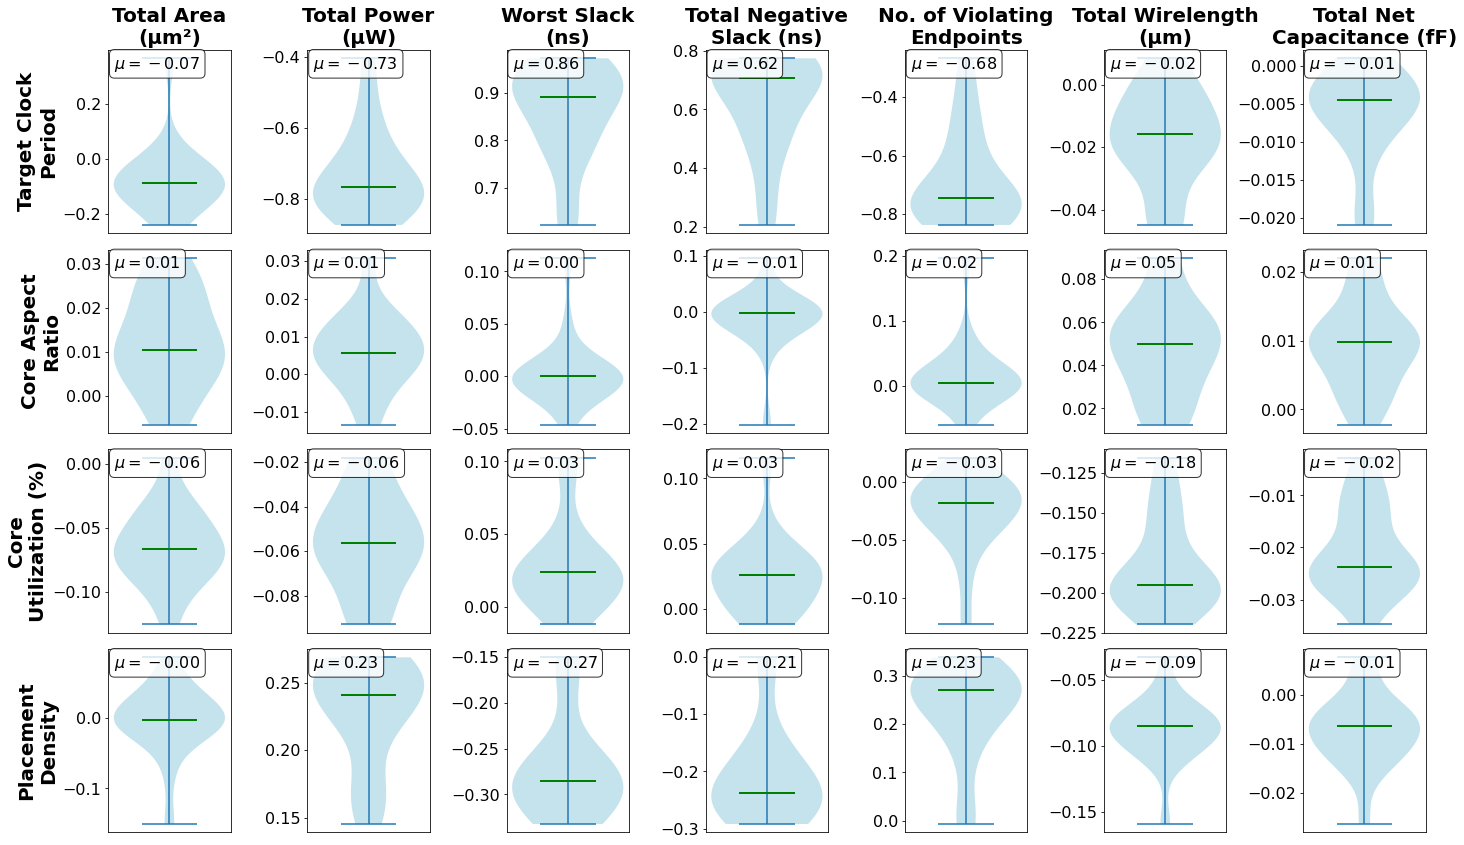

In [24]:
fig, axes = plt.subplots(len(PARAMETER_LABEL_DICT), len(PARAM_SENSITIVITY_METRIC_LABELS), figsize=(20, 12), sharey=False)

for i, metric_label in enumerate(PARAM_SENSITIVITY_METRIC_LABELS):
    for j, param_label in enumerate(PARAMETER_LABEL_DICT.values()):
        ax = axes[j, i]

        data = correlation_df[
            (correlation_df["metric"] == metric_label) &
            (correlation_df["parameter"] == param_label)
        ]["pearson_r"].dropna()

        if not data.empty:
            parts = ax.violinplot(data, showmedians=True, showextrema=True)

            for body in parts["bodies"]:
                body.set_facecolor("lightblue")
                body.set_alpha(0.7)

            parts["cmedians"].set_color("green")
            parts["cmedians"].set_linewidth(2)

            # Mean annotation
            mean_val = data.mean()
            ax.text(
                0.05, 0.90,
                f"$\\mu={mean_val:.2f}$",
                transform=ax.transAxes,
                fontsize=16,
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", alpha=0.8)
            )

        ax.set_xticks([])
        ax.tick_params(axis="y", labelsize=16)

        if j == 0:
            ax.set_title(metric_label, fontsize=20, fontweight="bold")
        if i == 0:
            ax.set_ylabel(param_label, fontsize=20, fontweight="bold")

plt.suptitle("")
plt.tight_layout()

# Save
fig.savefig(f"../results/{PDK}_correlation_violin.png", dpi=300)

plt.show()

## 9. Baseline Analysis

Analyze how well intermediate design stages predict final post-routing quality-of-results (QoR). This section evaluates stage-to-final agreement across physical, timing, and interconnect metrics. 

### Baseline Prediction Performance

Summarize stage-to-final prediction accuracy across key quality-of-results (QoR) metrics.

This table evaluates how well intermediate physical design stages approximate final detailed-route outcomes.

We compare:

- floorplan → detailed route  
- global placement → detailed route  
- detailed placement → detailed route  
- CTS → detailed route  
- global route → detailed route  

Metrics are grouped into:

- **Physical QoR:** total area, total power, wirelength  
- **Interconnect:** net-level interconnect length  
- **Timing QoR:** worst arrival time, worst slack, total negative slack  
- **Path-level timing:** arrival time, slack, arc delay, slew  

Evaluation metrics include:

- **MAE / MAPE:** absolute and relative prediction error  
- **R²:** goodness of fit  
- **MPE / MNE:** positive and negative error decomposition  
- **TPR / TNR:** sign classification accuracy for slack-based metrics  
- **P95 / TOP5:** tail and critical-path prediction error  

This baseline quantifies when metrics stabilize across the flow and identifies which intermediate stages provide reliable proxies for final post-route QoR.

In [25]:
df = pd.read_csv("../results/baseline_table.csv", header=[0, 1, 2])
df.columns = ['_'.join([str(i) for i in col if i and 'Unnamed' not in str(i)]).strip() for col in df.columns]
pdk_cols = [c for c in df.columns if PDK in c]
df_pdk = df[['Metric', 'Stat'] + pdk_cols]
df_pdk.set_index(['Metric', 'Stat'], inplace=True)

df_pdk

floorplan to detailed route_ASAP7  \
Metric                        Stat                                          
Total Area (μm²)              MAE                                  225.06   
                              MAPE                                 15.35%   
                              R2                                    0.969   
Total Power (μW)              MAE                                6,071.61   
                              MAPE                                 33.47%   
                              R2                                    0.823   
Total Wirelength (μm)         MAE                                     NaN   
                              MAPE                                    NaN   
                              R2                                      NaN   
Interconnect length (μm)      MAE                                     NaN   
                              MAPE                                    NaN   
                              R2                                      NaN   
                              MAE_P95                                 NaN   
                              MAPE_P95                                NaN   
                              MAE_TOP5                                NaN   
                              MAPE_TOP5                               NaN   
Worst Arrival Time (ns)       MAE                                    0.09   
                              MAPE                                 15.78%   
Worst Slack (ns)              MAE                                    0.03   
                              MPE                                    0.04   
                              MNE                                    0.02   
                              TPR                                  67.94%   
                              TNR                                  97.70%   
Total Negative Slack (ns)     MAE                                    1.09   
                              MPE                                    3.92   
                              MNE                                    2.10   
Timing Path Arrival Time (ns) MAE                                  0.1836   
                              MAPE                                 51.92%   
                              MAE_P95                              0.3296   
                              MAPE_P95                             74.00%   
                              MAE_TOP5                             0.3048   
                              MAPE_TOP5                            36.41%   
Timing Path Slack (ns)        MAE                                  0.0400   
                              MPE                                  0.0788   
                              MNE                                  0.0222   
                              TPR                                  70.21%   
                              TNR                                  99.96%   
Net Arc Delay (ns)            MAE                                  0.0105   
                              MAPE                                 39.38%   
                              R2                                      <-1   
Cell Arc Delay (ns)           MAE                                  0.0018   
                              MAPE                                >10000%   
                              R2                                   -0.141   
Cell Arc Slew (ns)            MAE                                  0.0152   
                              MAPE                                 34.33%   
                              R2                                      <-1   

                                        global place to detailed route_ASAP7  \
Metric                        Stat                                             
Total Area (μm²)              MAE                                      73.79   
                              MAPE                                     7.50%   
                       

### Baseline Prediction Trends

Visualize stage-to-final prediction agreement across physical, timing, and path-level metrics.

Each panel compares metric values at an intermediate design stage against final detailed-route values.

Columns represent prediction stage:

- floorplan → detailed route  
- global placement → detailed route  
- detailed placement → detailed route  
- CTS → detailed route  
- global route → detailed route  

Rows represent QoR metric groups:

- physical metrics: area, power, wirelength  
- interconnect metrics  
- timing closure metrics  
- path-level delay and slew metrics  

For each plot:

- blue points show individual samples  
- the red diagonal represents ideal prediction agreement  
- the green fit line shows observed correlation trend  
- slope and goodness-of-fit summarize predictive quality  

This visualization shows how prediction accuracy improves as the implementation flow progresses, highlighting which metrics converge early and which remain sensitive until late-stage routing.

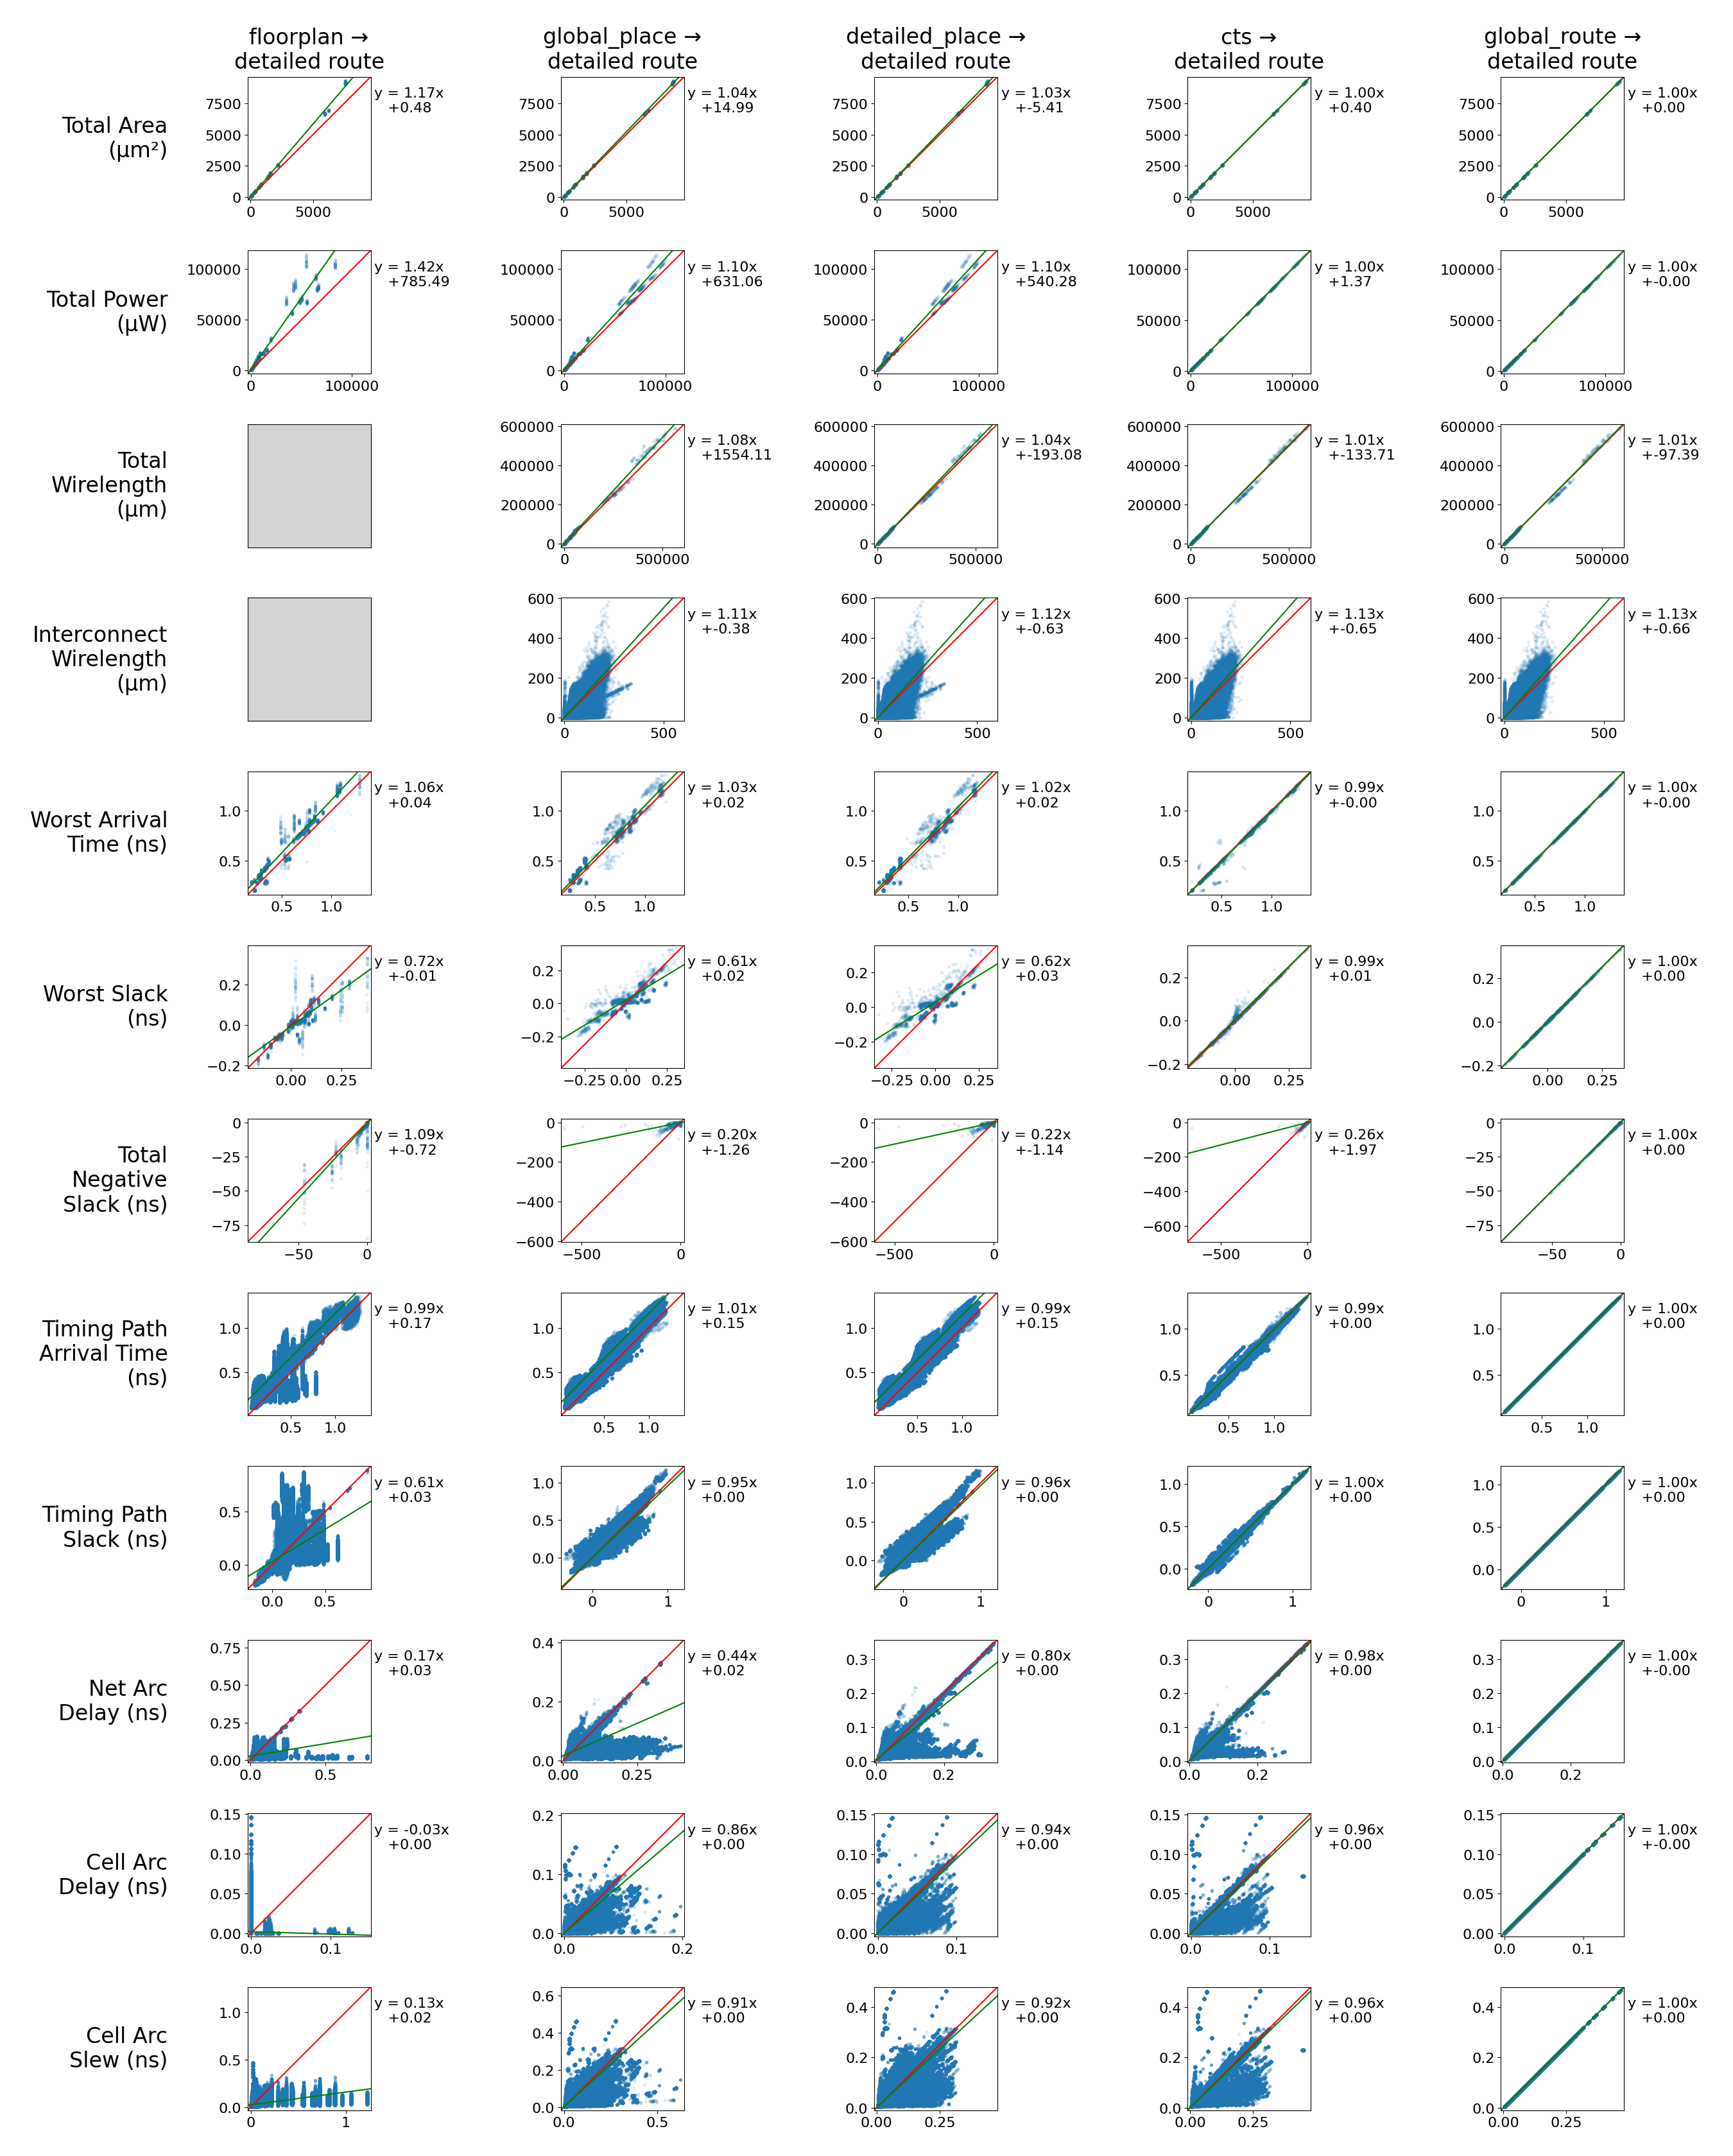

In [26]:
img_path = f"../results/{PDK}_baseline_grid.png"
display(Image(filename=img_path))

## Conclusions

This notebook presented a structured analysis of the **EDA-Schema V2 dataset** for the **ASAP7 7nm (ASAP7)** technology node covering dataset construction, design-space exploration, QoR characterization, timing behavior, inter-stage metric evolution, and baseline predictability. 

The analysis showed:

- substantial diversity in circuit scale, timing complexity, and physical implementation outcomes across designs  
- clear variation in power, performance, and area metrics across parameter sweeps  
- strong dependence of QoR on timing constraints, with clock period emerging as the dominant design parameter  
- meaningful but smaller effects from aspect ratio, utilization, and placement density on routing and timing behavior  
- large differences in timing closure difficulty across designs, reflected in slack, TNS, and violating path distributions  
- progressive stabilization of many QoR metrics as designs move through placement, CTS, and routing stages  
- strong late-stage predictability for most physical and timing metrics, particularly after CTS  

The baseline study further showed that prediction accuracy improves consistently as implementation advances through the flow. Physical metrics such as area and power converge relatively early, while timing and path-level delay metrics remain more stage sensitive until later optimization stages. This confirms that intermediate design representations contain increasingly predictive information about final post-route outcomes as the flow progresses. 

Overall, the dataset exhibits rich structural variation, broad QoR coverage, and strong stage-aware behavior, making it well suited for downstream machine learning tasks including QoR prediction, timing modeling, representation learning, and stage-aware design optimization.